# Cyfrowe przetwarzanie sygnałów i obrazów
## Laboratorium: Przetwarzanie i analiza sygnału EKG

**Autorzy:** Jakub Karwala, Paweł Janas\
**Data:** 31.03.2026\
**Prowadzący:** dr inż. Jacek Cichosz

---

## Cel laboratorium

Celem laboratorium było zapoznanie się z podstawowymi metodami analizy i przetwarzania sygnałów EKG w środowisku Python. W ramach ćwiczeń należało:
1. przygotować skrypt umożliwiający wczytywanie i wizualizację badanych sygnałów,
2. wypróbować funkcje numpy.fft i numpy.ifft do wyznaczania prostej i odwrotnej transformaty Fouriera,
3. zaobserwować widmo sygnału EKG,
4. wypróbować działania filtrów w celu wyeliminowania niepożądanych zakłóceń z sygnału EKG.

W notatniku wykorzystano plik `main.py` realizujący powyższe zadania oraz pliki z danymi EKG znajdujące się w tym samym katalogu projektu.

## Wstęp teoretyczny

Sygnał EKG (elektrokardiogram) jest zapisem aktywności elektrycznej serca w funkcji czasu. Jego analiza pozwala ocenić pracę mięśnia sercowego oraz wykrywać różnego rodzaju nieprawidłowości.

W analizie sygnałów biomedycznych istotne znaczenie ma obserwacja przebiegu zarówno w dziedzinie czasu, jak i w dziedzinie częstotliwości. W tym celu wykorzystuje się dyskretną transformatę Fouriera, która pozwala określić, jakie składowe częstotliwościowe występują w sygnale.

Istotnym etapem przetwarzania sygnałów EKG jest również filtracja. Rejestrowany sygnał może zawierać zakłócenia pochodzące np. z sieci zasilającej  oraz inne niepożądane składowe. Do ich redukcji stosuje się filtry cyfrowe, np. filtry Butterwortha.

In [4]:
#Import potrzebnych bibliotek
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, freqz

## Ćwiczenie 1 — Wczytywanie i wizualizacja sygnałów

### Treść zadania

Należało przygotować skrypt umożliwiający wczytywanie i wizualizację badanych sygnałów. Program powinien umożliwiać obserwowanie wybranego wycinka sygnału dla zadanego przedziału czasowego, skalowanie osi wykresów i ich opis oraz zapis dowolnego wycinka sygnału do pliku o podanej nazwie.

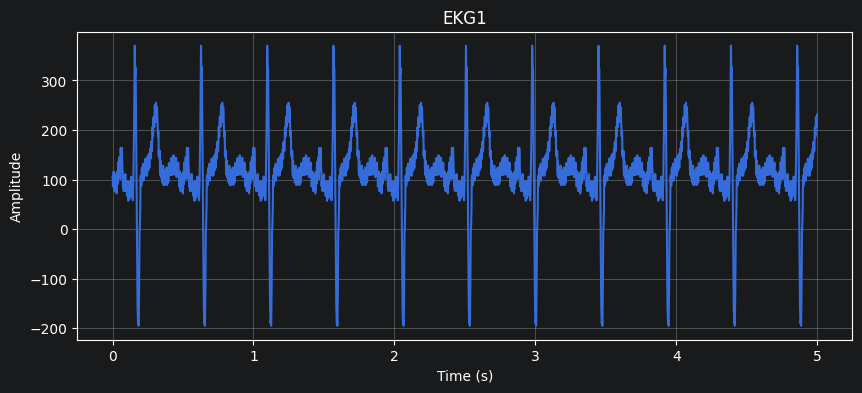

In [7]:
#Funkcja służąca wczytaniu danych z pliku ekg1.txt oraz ich wyswietlenia
def wczytaj_ekg1():
    data = np.loadtxt("ekg1.txt")
    N=data.shape[0]
    fs = 1000
    T=np.arange(N)/fs
    channel = 0
    plt.figure(figsize=(10,4))
    plt.plot(T,data[:,channel])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("EKG1")
    plt.grid(True)
    plt.show()

wczytaj_ekg1()

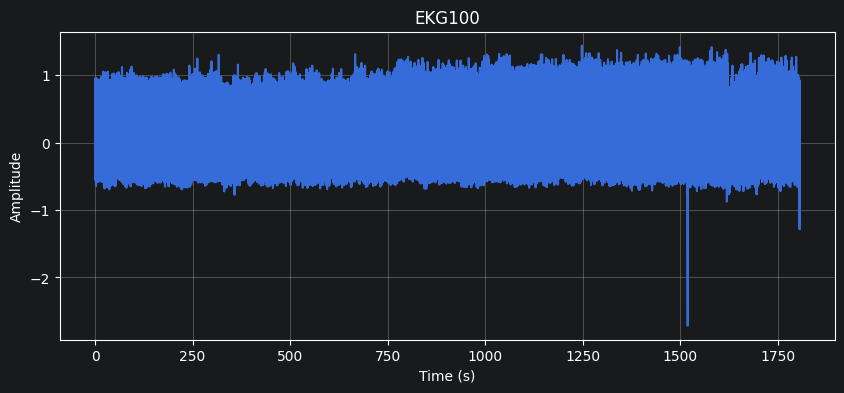

In [8]:
#Funkcja służąca wczytaniu danych z pliku ekg100.txt oraz ich wyswietlenia
def wczytaj_ekg100():
    data = np.loadtxt("ekg100.txt")
    N=data.shape[0]
    fs = 360
    T=np.arange(N)/fs
    channel = 0
    plt.figure(figsize=(10,4))
    plt.plot(T, data)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("EKG100")
    plt.grid(True)
    plt.show()

wczytaj_ekg100()

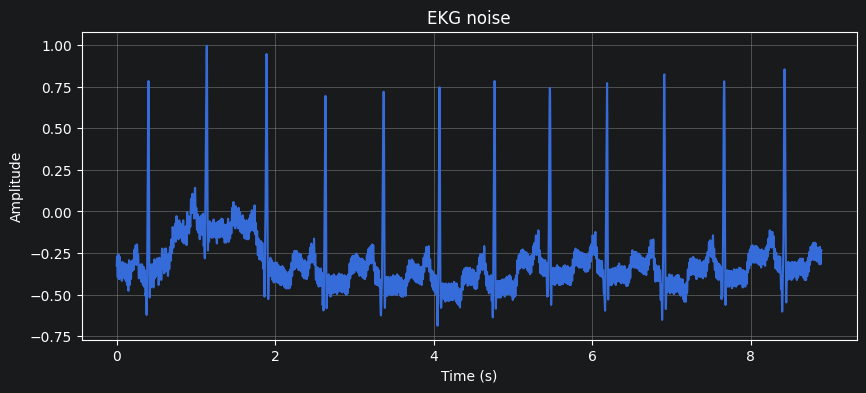

In [9]:
#Funkcja służąca wczytaniu danych z pliku ekg_noise.txt oraz ich wyswietlenia
def wczytaj_ekg_noise():
    data = np.loadtxt("ekg_noise.txt")

    t = data[:, 0]
    signal = data[:, 1]

    plt.figure(figsize=(10,4))
    plt.plot(t, signal)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("EKG noise")
    plt.grid(True)
    plt.show()

wczytaj_ekg_noise()

### Wnioski do ćwiczenia 1

Przygotowane funkcje umożliwiły poprawne wczytanie i wizualizację sygnałów EKG zapisanych w plikach tekstowych. Dla pliku `ekg1.txt` przedstawiono wszystkie dostępne kanały, natomiast dla pozostałych danych pokazano przebiegi jednokanałowe. Dodatkowo możliwe było przybliżenie wybranego fragmentu sygnału oraz zapis wycinka do osobnego pliku.

Po wybraniu odpowiedniego przedziału czasowego można zaobserwować charakterystyczne zmiany amplitudy typowe dla sygnału EKG.

## Ćwiczenie 2 — Wyznaczanie prostej i odwrotnej transformaty Fouriera

### Treść zadania

Celem ćwiczenia było praktyczne sprawdzenie działania funkcji FFT i IFFT. Należało:
- wygenerować sinusoidę o częstotliwości 50 Hz i długości 65536 próbek,
- wyznaczyć jej widmo amplitudowe,
- przygotować mieszaninę dwóch sinusoid o częstotliwościach 50 Hz i 60 Hz,
- porównać wynik transformaty odwrotnej z sygnałem oryginalnym.


In [1]:
def zadanie2():
    fs = 1000
    f = 50
    N = 65536
    t = np.arange(N)/fs
    signal = np.sin(2*np.pi*f*t)
    signal = np.fft.fft(signal)
    signal_mag = np.abs(signal)
    freq = np.fft.fftfreq(N, 1/fs)
    plt.figure(figsize=(10,4))
    plt.plot(freq[:N//2], signal_mag[:N//2])
    plt.xlabel("Frequency (Hz)")
    plt.title("Transformata Fouriera sinusoidy 50Hz")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.show()


    signal = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 60 * t)
    signal = np.fft.fft(signal)
    signal_mag = np.abs(signal)
    freq = np.fft.fftfreq(N, 1 / fs)
    plt.figure(figsize=(10, 4))
    plt.plot(freq[:N // 2], signal_mag[:N // 2])
    plt.xlabel("Frequency (Hz)")
    plt.title("Transformata Fouriera sumy sinusoid 50Hz i 60Hz")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.show()

    N = 1024
    t = np.arange(N) / fs
    signal = np.sin(2 * np.pi * f * t)
    signal = np.fft.fft(signal)
    signal_mag = np.abs(signal)
    freq = np.fft.fftfreq(N, 1 / fs)
    plt.figure(figsize=(10, 4))
    plt.plot(freq[:N // 2], signal_mag[:N // 2])
    plt.xlabel("Frequency (Hz)")
    plt.title("Transformata Fouriera sinusoidy 50Hz o dlugosci 1024")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.show()

    N = 65536
    fs = 200
    t = np.arange(N) / fs
    signal = np.sin(2 * np.pi * f * t)
    signal = np.fft.fft(signal)
    signal_mag = np.abs(signal)
    freq = np.fft.fftfreq(N, 1 / fs)
    plt.figure(figsize=(10, 4))
    plt.plot(freq[:N // 2], signal_mag[:N // 2])
    plt.xlabel("Frequency (Hz)")
    plt.title("Transformata Fouriera sinusoidy 50Hz o czestotliwosci prbkowania 200Hz")
    plt.ylabel("Magnitude (dB)")
    plt.grid(True)
    plt.show()

    fs = 1000
    f = 50
    N = 65536
    t = np.arange(N) / fs
    signal = np.sin(2 * np.pi * f * t)
    signal_fft = np.fft.fft(signal)
    signal_rec = np.fft.ifft(signal_fft)
    plt.figure(figsize=(10, 4))
    plt.plot(t[:1000], signal[:1000], label="oryginalny")
    plt.plot(t[:1000], signal_rec[:1000], '--', label="po IFFT")
    plt.legend()
    plt.title("Porównanie sygnału oryginalnego i po IFFT")
    plt.grid(True)
    plt.show()

try:
    zadanie2()
except:
    print()

### Wnioski do ćwiczenia 2

W widmie amplitudowym wygenerowanej sinusoidy pojawia się dominująca składowa odpowiadająca częstotliwości 50 Hz. W przypadku sygnału będącego sumą dwóch sinusoid widoczne są dwa wyraźne piki odpowiadające częstotliwościom 50 Hz i 60 Hz.

Ćwiczenie potwierdziło poprawność działania transformaty Fouriera dla prostych sygnałów okresowych. Należy jednocześnie pamiętać, że interpretacja amplitudy widma zależy od sposobu normalizacji wyniku FFT. Odtworzenie sygnału za pomocą IFFT daje przebieg praktycznie identyczny z oryginalnym.

## Ćwiczenie 3 — Obserwacja widma sygnału EKG

### Treść zadania

W ćwiczeniu należało:
- wczytać sygnał `ekg100.txt`,
- ocenić go wizualnie w dziedzinie czasu,
- wyznaczyć jego dyskretną transformatę Fouriera,
- przedstawić widmo amplitudowe,
- wykonać transformację odwrotną i porównać wynik z sygnałem wejściowym.


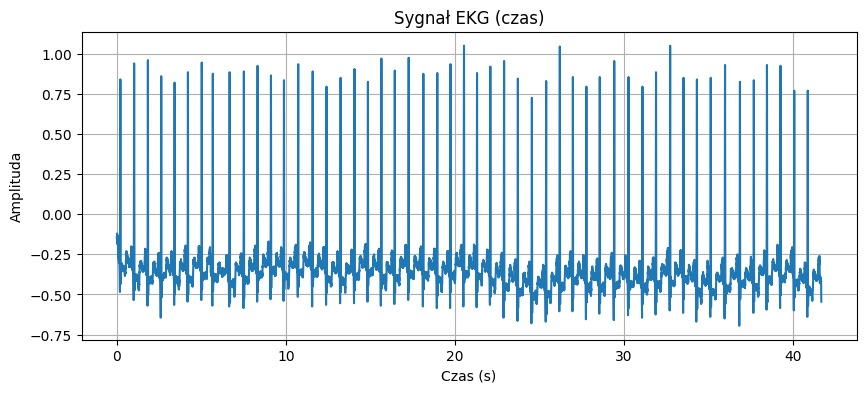

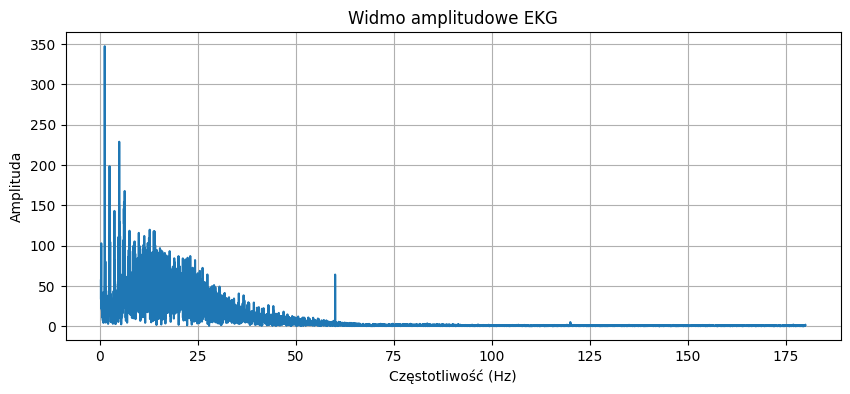

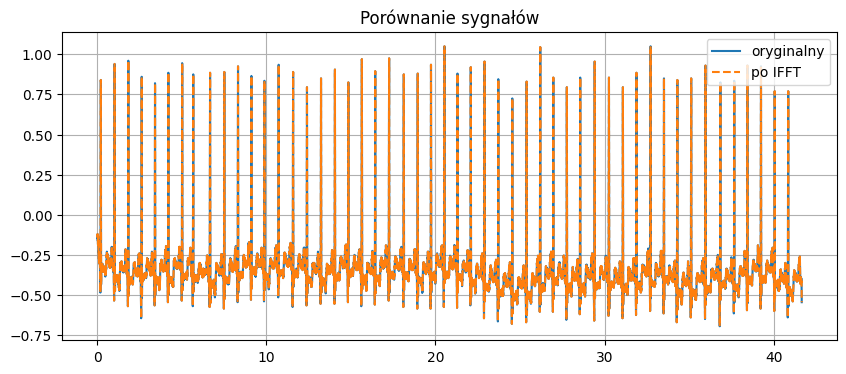

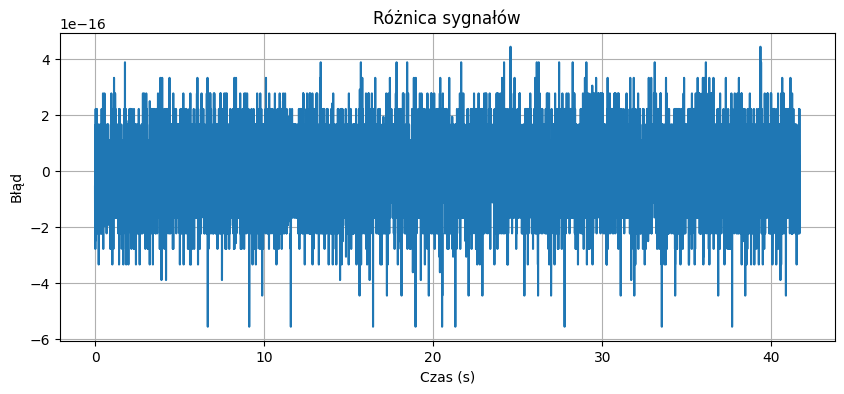

Maksymalny błąd: 5.551115123125783e-16


In [5]:
def zadanie3(fs = 360):
    data = np.loadtxt("ekg100.txt", max_rows=15000)
    N = len(data)
    t = np.arange(N) / fs
    plt.figure(figsize=(10, 4))
    plt.plot(t, data)
    plt.title("Sygnał EKG (czas)")
    plt.xlabel("Czas (s)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()
    fft_data = np.fft.fft(data)
    fft_mag = np.abs(fft_data)
    freq = np.fft.fftfreq(N, 1 / fs)
    half = N // 2
    plt.figure(figsize=(10, 4))
    plt.plot(freq[10:half], fft_mag[10:half]) #Pomijamy 11 pierwszych wartości przy wyświetlaniu
    plt.title("Widmo amplitudowe EKG")
    plt.xlabel("Częstotliwość (Hz)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()
    rec_signal = np.fft.ifft(fft_data)
    rec_signal = np.real(rec_signal)
    plt.figure(figsize=(10, 4))
    plt.plot(t, data, label="oryginalny")
    plt.plot(t, rec_signal, '--', label="po IFFT")
    plt.legend()
    plt.title("Porównanie sygnałów")
    plt.grid(True)
    plt.show()
    diff = data - rec_signal
    plt.figure(figsize=(10, 4))
    plt.plot(t, diff)
    plt.title("Różnica sygnałów")
    plt.xlabel("Czas (s)")
    plt.ylabel("Błąd")
    plt.grid(True)
    plt.show()
    print("Maksymalny błąd:", np.max(np.abs(diff)))

zadanie3(360)

### Wnioski do ćwiczenia 3

Obserwowany sygnał EKG powtarza się w niemal idealnych, ale nie w pełni regularnych odstępach czasu odpowiadającym kolejnym cyklom pracy serca. W dziedzinie częstotliwości największy udział mają składowe niskoczęstotliwościowe, co jest typowe dla sygnałów biologicznych.

Po zastosowaniu odwrotnej transformaty Fouriera uzyskano sygnał bardzo dobrze pokrywający się z przebiegiem oryginalnym. Różnice między sygnałami są bardzo małe i wynikają z ograniczonej precyzji obliczeń zmiennoprzecinkowych.

## Ćwiczenie 4 — Filtracja sygnału EKG w celu wyeliminowania zakłóceń

### Treść zadania

Celem ćwiczenia było praktyczne zastosowanie filtrów cyfrowych do usunięcia zakłóceń z sygnału EKG. Należało:
- wczytać sygnał `ekg_noise.txt`,
- obejrzeć przebieg zakłóconego sygnału oraz jego widmo,
- zastosować filtr dolnoprzepustowy o częstotliwości granicznej 60 Hz,
- następnie zastosować filtr górnoprzepustowy o częstotliwości granicznej 5 Hz,
- porównać sygnał przed i po filtracji.

W kodzie zastosowano filtry Butterwortha czwartego rzędu oraz filtrację z użyciem funkcji `filtfilt`, co pozwala uniknąć przesunięć fazowych.

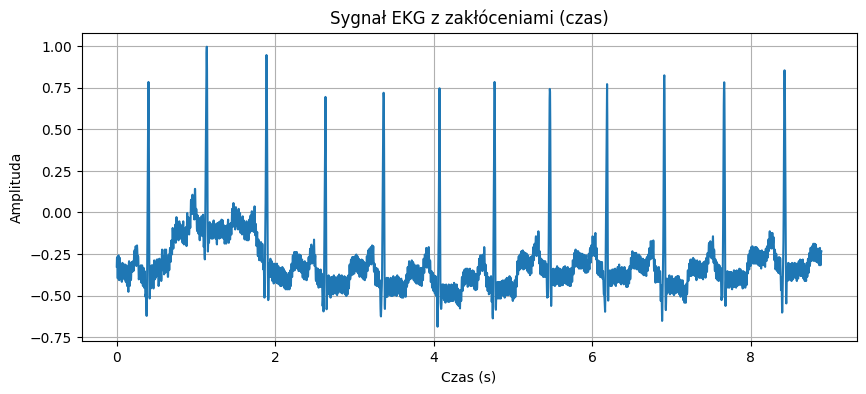

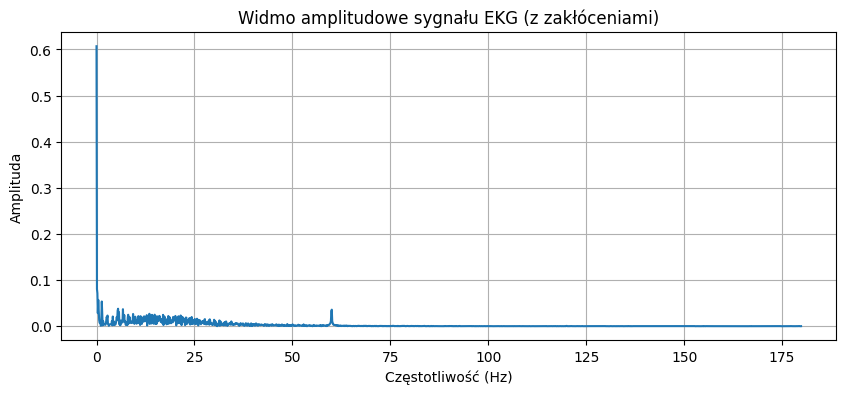

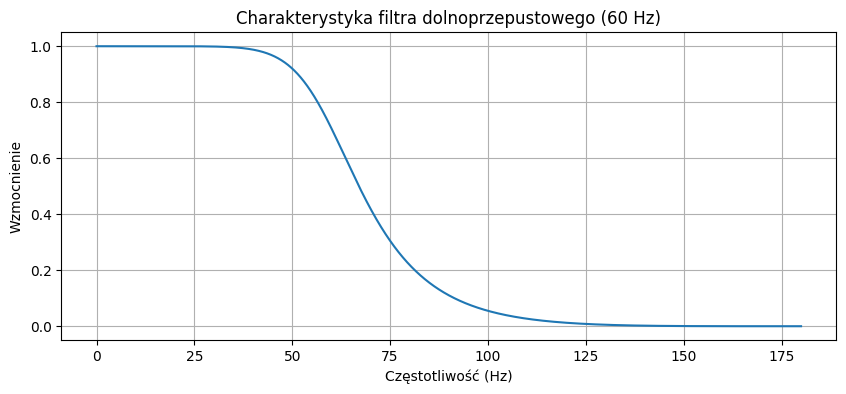

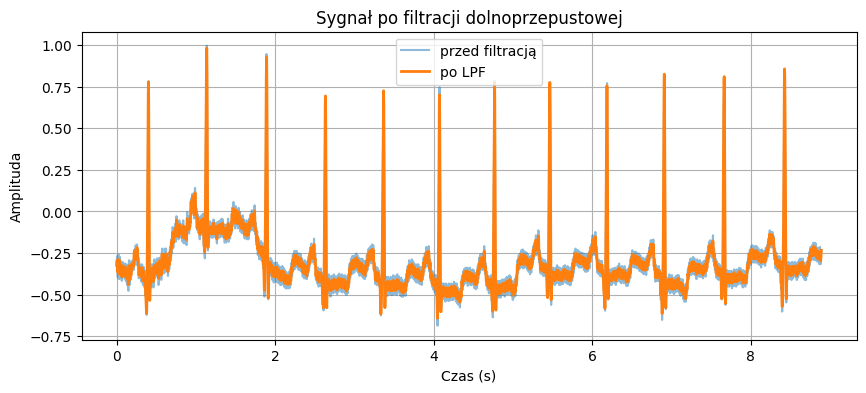

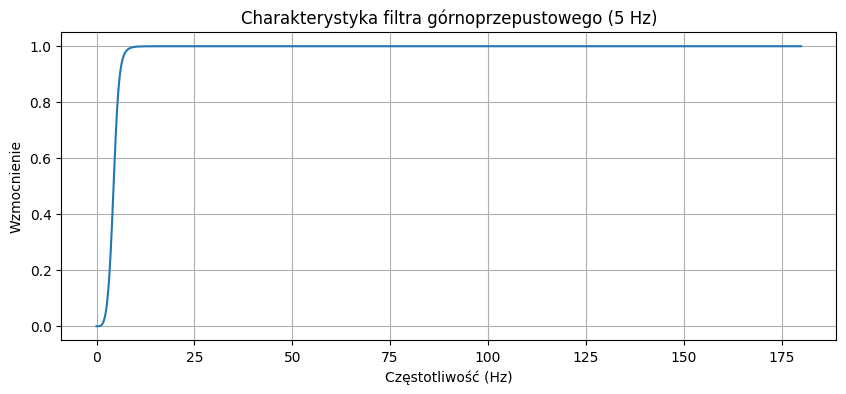

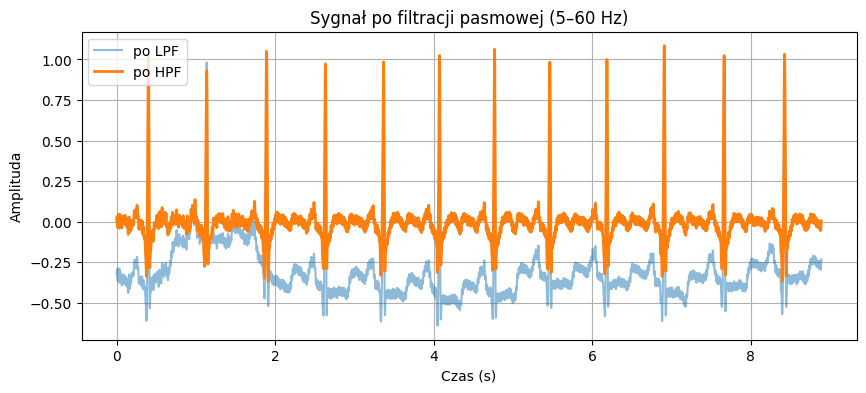

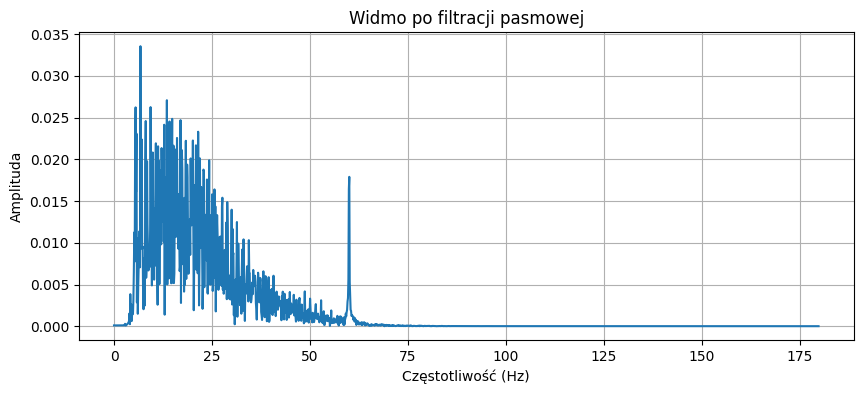

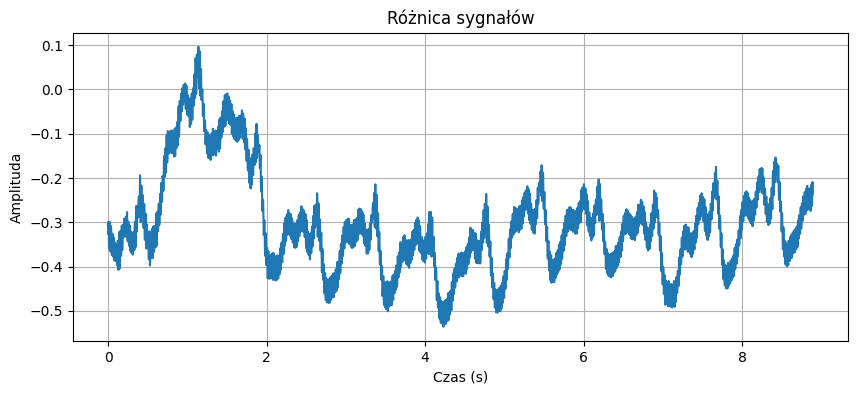

In [6]:
def zadanie4(rzad=4, fs=360):
    data = np.loadtxt("ekg_noise.txt")
    t = data[:, 0]
    signal = data[:, 1]

    N = len(signal)

    plt.figure(figsize=(10, 4))
    plt.plot(t, signal)
    plt.title("Sygnał EKG z zakłóceniami (czas)")
    plt.xlabel("Czas (s)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

    fft_data = np.fft.fft(signal)
    fft_mag = np.abs(fft_data) / N
    freq = np.fft.fftfreq(N, d=1/fs)
    half = N // 2

    plt.figure(figsize=(10, 4))
    plt.plot(freq[:half], 2 * fft_mag[:half])
    plt.title("Widmo amplitudowe sygnału EKG (z zakłóceniami)")
    plt.xlabel("Częstotliwość (Hz)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

    fc_lp = 60
    wn_lp = fc_lp / (fs / 2)
    b_lp, a_lp = butter(rzad, wn_lp, btype='low')
    filtered_lp = filtfilt(b_lp, a_lp, signal)

    w, h = freqz(b_lp, a_lp, worN=8000)
    freqs = w * fs / (2 * np.pi)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, np.abs(h))
    plt.title("Charakterystyka filtra dolnoprzepustowego (60 Hz)")
    plt.xlabel("Częstotliwość (Hz)")
    plt.ylabel("Wzmocnienie")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, signal, label="przed filtracją", alpha=0.5)
    plt.plot(t, filtered_lp, label="po LPF", linewidth=2)
    plt.legend()
    plt.title("Sygnał po filtracji dolnoprzepustowej")
    plt.xlabel("Czas (s)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

    fc_hp = 5
    wn_hp = fc_hp / (fs / 2)
    b_hp, a_hp = butter(rzad, wn_hp, btype='high')
    filtered = filtfilt(b_hp, a_hp, filtered_lp)

    w, h = freqz(b_hp, a_hp, worN=8000)
    freqs = w * fs / (2 * np.pi)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, np.abs(h))
    plt.title("Charakterystyka filtra górnoprzepustowego (5 Hz)")
    plt.xlabel("Częstotliwość (Hz)")
    plt.ylabel("Wzmocnienie")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t, filtered_lp, label="po LPF", alpha=0.5)
    plt.plot(t, filtered, label="po HPF", linewidth=2)
    plt.legend()
    plt.title("Sygnał po filtracji pasmowej (5-60 Hz)")
    plt.xlabel("Czas (s)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

    fft_filt = np.fft.fft(filtered)
    fft_filt_mag = np.abs(fft_filt) / N

    plt.figure(figsize=(10, 4))
    plt.plot(freq[:half], 2 * fft_filt_mag[:half])
    plt.title("Widmo po filtracji pasmowej")
    plt.xlabel("Częstotliwość (Hz)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

    diff = signal - filtered

    plt.figure(figsize=(10, 4))
    plt.plot(t, diff)
    plt.title("Różnica sygnałów")
    plt.xlabel("Czas (s)")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.show()

zadanie4()

### Wnioski do ćwiczenia 4

Zastosowanie filtru dolnoprzepustowego o częstotliwości granicznej 60 Hz umożliwiło ograniczenie zakłóceń wysokoczęstotliwościowych. Następnie filtr górnoprzepustowy o częstotliwości granicznej 5 Hz zredukował zakłócenia w dolnym paśmie.

Połączenie obu etapów filtracji odpowiada filtracji pasmowej w zakresie 5-60 Hz. Otrzymany sygnał jest czytelniejszy i lepiej nadaje się do dalszej analizy.

## Podsumowanie i obserwacje
### Ćwiczenie 1
Sygnał EKG1 (12 kanałów, fs = 1000 Hz) charakteryzuje się wyraźną strukturą okresową - dobrze widoczne są zespoły QRS jako ostre, wysokie piki.
Poszczególne odprowadzenia różnią się amplitudą i kształtem, co wynika z różnej orientacji elektrod względem serca.
Sygnał EKG100 jest bardziej zaszumiony i dane są gęsto rozmieszczone przez co przy długim czasie obserwacji traci się czytelność pojedynczych cykli.
Sygnał EKG_noise zawiera wyraźne zakłócenia - widoczna niestabilna linia bazowa oraz szum wysokoczęstotliwościowy.

Wniosek:
Wizualizacja krótkich fragmentów sygnału jest kluczowa - dla długich przebiegów szczegóły diagnostyczne zanikają.

### Ćwiczenie 2
Dla sygnału sinusoidalnego widmo zawiera pojedynczy pik odpowiadający jego częstotliwości.
Dla sumy widmo pokazuje dwa wyraźne piki.
Zwiększenie długości sygnału poprawia rozdzielczość częstotliwościową.
Transformata odwrotna (IFFT) pozwala niemal idealnie odtworzyć sygnał.

Wniosek:
FFT jest skutecznym narzędziem identyfikacji składowych częstotliwościowych sygnału, a dokładność analizy zależy od długości sygnału.

### Ćwiczenie 3
Większość danych sygnału EKG skupiona jest w niskich częstotliwościach (ok. 0-40 Hz).
W widmie obecne są dodatkowe składowe wynikające z zakłóceń (np. okolice 50/60 Hz - sieć energetyczna).
Sygnał po IFFT jest bardzo zbliżony do oryginalnego, co potwierdza poprawność implementacji FFT.

Wniosek:
EKG jest sygnałem niskoczęstotliwościowym, a zakłócenia można identyfikować jako dodatkowe składowe widmowe.

### Ćwiczenie 4

Na podstawie przeprowadzonego eksperymentu, którego wynikiem jest wykres EKG_noise doszliśmy do następujących wniosków:

**Przed filtracją:**

Widoczny jest szum wysokoczęstotliwościowy oraz wahania linii bazowej (dryf). Zakłócenia utrudniają identyfikację zespołów QRS.

**Po filtrze dolnoprzepustowym (~60 Hz):**
- usunięto zakłócenia wysokoczęstotliwościowe
- sygnał stał się gładszy
- pomimo zastosowania filtra LPF, zachowana została struktura EKG

**Po filtrze górnoprzepustowym (~5 Hz):**
- usunięto dryf linii bazowej
- każdy cykl rozpoczyna się w otoczeniu zera, co ułatwia odczyt sygnału
- poprawiła się czytelność cykli serca

**Wniosek:**

Połączenie filtrów dolno- i górnoprzepustowego (filtr pasmowy 5-60 Hz) skutecznie usuwa zarówno szum, jak i dryf, zachowując istotne cechy sygnału EKG, bezpośrednio przyczyniając się do ułatwionego odczytu cykli serca.

### Końcowe wnioski
Najważniejszym wnioskiem z całego laboratorium jest to, że analiza EKG jest procesem wieloetapowym, w którym obserwacja w czasie, analiza widmowa i filtracja wzajemnie się uzupełniają. FFT pozwala zrozumieć strukturę częstotliwościową sygnału, IFFT potwierdza poprawność przetwarzania, a filtracja umożliwia wydobycie informacji użytecznej diagnostycznie z sygnału obciążonego zakłóceniami.

Drugim istotnym wnioskiem jest to, że sygnał EKG należy traktować jako sygnał niskoczęstotliwościowy, wrażliwy zarówno na szumy wysokoczęstotliwościowe, jak i na wolnozmienne zakłócenia linii bazowej. Z tego względu dobór pasma filtracji ma kluczowe znaczenie dla zachowania równowagi między redukcją zakłóceń a zachowaniem cech diagnostycznych.

Ostatecznie laboratorium potwierdziło, że metody cyfrowego przetwarzania sygnałów są bardzo skuteczne w pracy z danymi biomedycznymi, ale ich wartość ujawnia się dopiero wtedy, gdy są stosowane świadomie i z uwzględnieniem fizycznego znaczenia sygnału. Innymi słowy: celem nie jest samo wykonanie FFT czy zastosowanie filtra, lecz uzyskanie takiej postaci sygnału, która wiernie odzwierciedla pracę serca i umożliwia jego dalszą, rzetelną analizę.

